# k Nearest Neighbors (kNN)

**k Nearest Neighbors (kNN)** is a **supervised machine learning algorithm** used for both **classification** and **regression**. It predicts the output of a new data point by finding the **k nearest training data points (neighbors)**. The basic assumption of kNN is that **similar data points are likely to have similar outputs**. In other words, if two data points are close to each other, they usually belong to the same class or have similar target values.

Unlike algorithms such as **Linear Regression**, **Logistic Regression**, or **Naive Bayes**, kNN does **not learn any mathematical equation or decision boundary during training**. Instead, it simply stores the complete training dataset and uses it whenever a prediction is required.

---

# Why is it called k Nearest Neighbors?

The name **k Nearest Neighbors** has three parts:

- **k** represents the **number of nearest data points** considered for making a prediction.
- **Nearest** means the data points that are **closest** to the new sample based on a distance metric.
- **Neighbors** are the training samples located nearest to the new data point.

For example, if **k = 5**, the algorithm finds the **5 closest training samples** and uses only those samples to make the prediction.

---

# Why is kNN called a Lazy Learner?

kNN is known as a **Lazy Learning Algorithm** because it **does not learn a model during training**. Instead of analyzing the data and creating a mathematical function, it simply **memorizes the entire training dataset**.

During the prediction phase, the algorithm compares the new data point with all the stored training samples, calculates the distance to each one, selects the nearest neighbors, and finally predicts the output.

> **Training Phase:** Store (memorize) the training dataset.

> **Prediction Phase:** Calculate distances → Find nearest neighbors → Make prediction.

Because of this behavior:

- **Training is very fast** since no model is built.
- **Prediction is slower** because distances must be calculated every time a new sample is given.

---

# How does kNN memorize data?

Unlike many machine learning algorithms, kNN **does not perform any learning during training**. It simply stores every training sample along with its corresponding target value (class label or numerical value).

For example, consider the following training dataset:

| Height (cm) | Weight (kg) | Class |
|-------------|-------------|--------|
| 170 | 65 | Fit |
| 165 | 58 | Fit |
| 182 | 92 | Unfit |
| 178 | 88 | Unfit |

During training, kNN simply stores this table in memory. No equations, weights, probability calculations, or optimization techniques are performed.

Whenever a new sample arrives, the stored data is used to make a prediction.

---

# Working of kNN

The kNN algorithm follows a series of simple steps to make predictions.

### Step 1: Choose the value of **k**

The first step is to choose the number of neighbors (**k**) that will participate in making the prediction.

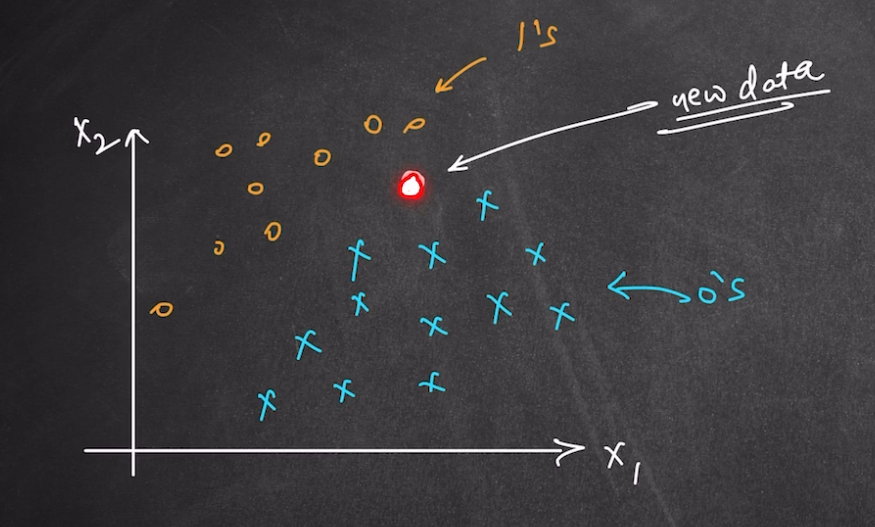

The value of **k** is called a **hyperparameter** because it is selected before training begins.

A small value of **k** considers fewer neighbors, making the model sensitive to noise. A larger value considers more neighbors, producing smoother predictions.

For binary classification, an **odd value** (3, 5, 7, ...) is usually preferred to reduce the chance of ties.

---

### Step 2: Calculate the distance

The algorithm calculates the distance between the **new data point** and **every training sample**.

The smaller the distance, the more similar the data points are.

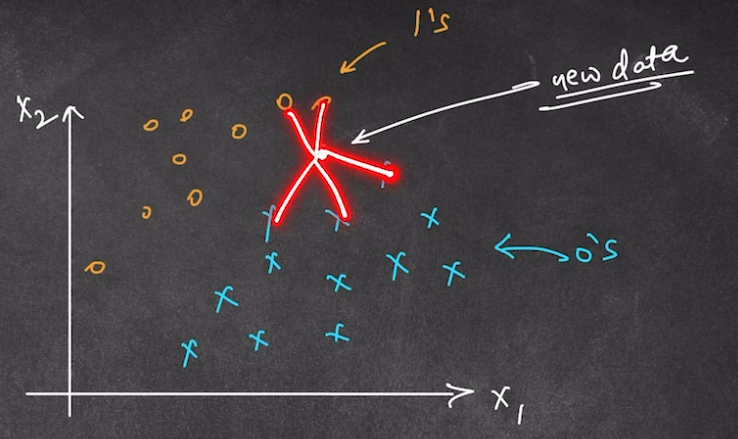

After calculating all distances:

- Sort the distances in ascending order.
- Select the **k nearest neighbors**.

---

### Step 3: Select the nearest neighbors

Once all distances are calculated, the algorithm keeps only the **k closest training samples** and ignores the remaining data.

These nearest neighbors are considered the most relevant for making the prediction.

---

### Step 4: Make the prediction

The prediction method depends on the type of machine learning problem.

### Classification

For classification problems, kNN uses **Majority Voting**.

The class that appears **most frequently** among the k nearest neighbors becomes the predicted class.

**Example**

Suppose **k = 5**.

| Neighbor | Class |
|----------|-------|
| 1 | A |
| 2 | A |
| 3 | B |
| 4 | A |
| 5 | B |

Since **Class A appears 3 times** and **Class B appears 2 times**, the predicted class will be:

> **Prediction = Class A**

---

### Regression

For regression problems, kNN calculates the **average (mean)** of the target values of the nearest neighbors.

**Example**

Nearest target values:

```
20
22
24
26
28
```

Prediction

$$
\frac{20+22+24+26+28}{5}=24
$$

So,

> **Prediction = 24**

---

# Distance Measures

Distance measures how close two data points are. The **smaller the distance**, the more similar the points are.

---

## Euclidean Distance

Euclidean Distance measures the **straight-line distance** between two points. It is the **most commonly used distance metric** in kNN.

The formula is:

$$
d=\sqrt{(x_1-x_2)^2+(y_1-y_2)^2}
$$

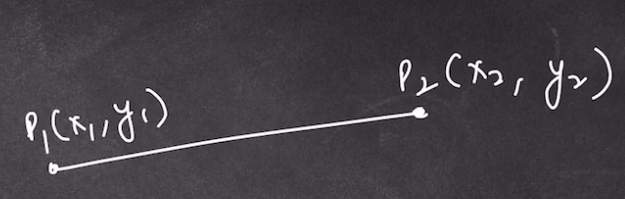

It works well when features are continuous and measured on similar scales.

---

## Manhattan Distance

Manhattan Distance measures the distance by moving **horizontally and vertically**, similar to travelling through city streets arranged in a grid.

The formula is:

$$
d=|x_1-x_2|+|y_1-y_2|
$$

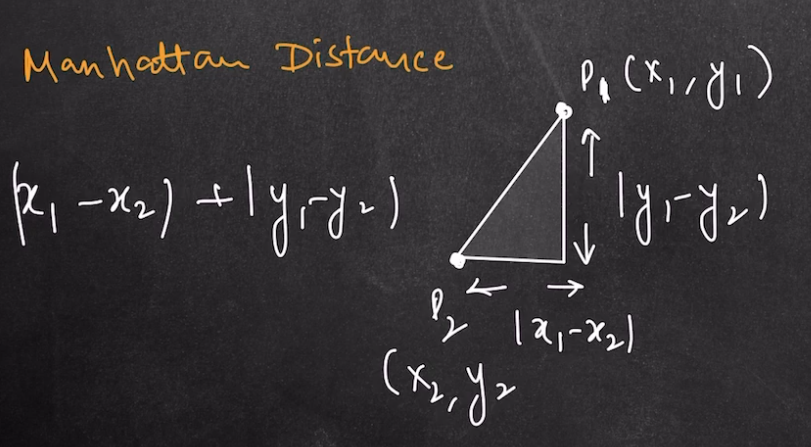

It is useful when movement is restricted to horizontal and vertical directions or when grid-based distances are more appropriate.

---

# Choosing the value of k

The choice of **k** has a significant impact on the performance of the algorithm.

### Small value of k

A small value (such as **k = 1** or **k = 3**) considers only a few neighbors. The prediction becomes highly dependent on nearby data points, making the model sensitive to noise and outliers.

### Large value of k

A large value (such as **k = 15** or **k = 21**) considers many neighbors. Predictions become smoother and more stable, but important local patterns may be ignored.

In practice, the best value of **k** is usually found through experimentation or cross-validation.

---

# Applications

kNN is widely used in many real-world applications because of its simplicity and effectiveness.

- **Image Classification:** Identify objects or handwritten digits by comparing similar images.
- **Recommendation Systems:** Recommend products or movies based on similar users.
- **Medical Diagnosis:** Predict diseases by comparing patients with similar symptoms.
- **Pattern Recognition:** Recognize faces, fingerprints, or speech patterns.
- **Fraud Detection:** Identify unusual transactions by comparing them with previous records.

---

# Important Points to Remember

- **kNN is a supervised learning algorithm.**
- It is used for both **classification** and **regression**.
- **Scaling** is very very important in kNN. Data must be scaled.
- It is called a **Lazy Learner** because it memorizes the training data instead of learning a model.
- The algorithm stores the **entire training dataset** during training.
- Prediction is made by finding the **k nearest neighbors**.
- **Classification** uses **majority voting**.
- **Regression** uses the **average** of the nearest neighbors.
- **Euclidean Distance** is the most commonly used distance metric.
- The choice of **k** directly affects the model's performance.

# Implementation

In [3]:
import pandas as pd
from sklearn.metrics import precision_score, accuracy_score, recall_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

In [4]:
heart_df=pd.read_csv("heart.csv")

In [5]:
X = heart_df.drop("target", axis=1)
y = heart_df["target"]

X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42
)

In [6]:
# Scaling - very important in kNN

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [7]:
# k=3
knn_classifier = KNeighborsClassifier(n_neighbors=3)
knn_classifier.fit(X_train_scaled, y_train)

y_pred = knn_classifier.predict(X_test_scaled)


In [8]:
print("recall score: ", recall_score(y_test, y_pred))
print("accuracy score: ", accuracy_score(y_test, y_pred) )
print("precision score: ", precision_score(y_test, y_pred))

recall score:  0.78125
accuracy score:  0.8524590163934426
precision score:  0.9259259259259259


In [9]:
# k=5
knn_classifier = KNeighborsClassifier(n_neighbors=5)
knn_classifier.fit(X_train_scaled, y_train)

y_pred = knn_classifier.predict(X_test_scaled)

print("recall score: ", recall_score(y_test, y_pred))
print("accuracy score: ", accuracy_score(y_test, y_pred) )
print("precision score: ", precision_score(y_test, y_pred))

recall score:  0.875
accuracy score:  0.9016393442622951
precision score:  0.9333333333333333


In [10]:
# k=7 --- best score till now 
knn_classifier = KNeighborsClassifier(n_neighbors=7)
knn_classifier.fit(X_train_scaled, y_train)

y_pred = knn_classifier.predict(X_test_scaled)

print("recall score: ", recall_score(y_test, y_pred))
print("accuracy score: ", accuracy_score(y_test, y_pred) )
print("precision score: ", precision_score(y_test, y_pred))

recall score:  0.90625
accuracy score:  0.9180327868852459
precision score:  0.9354838709677419


In [11]:
# much better performance than logistic regression for this dataset.

# Cross Validation using GridSearchCV

In [19]:
# Cross Validation for hyperparam tuning using GridSearchCV

from sklearn.model_selection import GridSearchCV

classifier = KNeighborsClassifier()
param_grid = {"n_neighbors": [3, 5, 7, 9]}

classifierCV = GridSearchCV(
    classifier,
    param_grid,
    cv=5,
    scoring="recall"
)

classifierCV.fit(X_train_scaled, y_train)

y_pred = classifierCV.predict(X_test_scaled)

print("recall score: ", recall_score(y_test, y_pred))
print("accuracy score: ", accuracy_score(y_test, y_pred))
print("precision score: ", precision_score(y_test, y_pred))

# results
res = pd.DataFrame(classifierCV.cv_results_)
print(res[["param_n_neighbors", "mean_test_score"]])

print(classifierCV.best_params_)

# 7 is the best k value after cross validation( on the basis of recall), which is more reliable

recall score:  0.90625
accuracy score:  0.9180327868852459
precision score:  0.9354838709677419
   param_n_neighbors  mean_test_score
0                  3         0.864387
1                  5         0.857550
2                  7         0.871795
3                  9         0.856980
{'n_neighbors': 7}


# Limitations of kNN

Although **kNN** is simple and effective, it has several limitations that can affect its performance, especially when working with large or complex datasets.

---

### 1. Slow Predictions

kNN performs almost no computation during training because it simply stores the training data. However, during prediction, it must calculate the distance between the new data point and **every training sample** before making a decision.

As the size of the dataset increases, the number of distance calculations also increases, making predictions slower.

> **Large Dataset → More Distance Calculations → Slower Predictions**

---

### 2. Memory Intensive

Since kNN stores the **entire training dataset**, it requires a large amount of memory, especially for large datasets.

Unlike many machine learning algorithms that only store a trained model, kNN keeps all training samples in memory.

> **More Training Data → Higher Memory Usage**

---

### 3. Sensitive to Outliers

An **outlier** is a data point that is very different from the rest of the data.

If the value of **k** is small (for example, **k = 1**), an outlier may become the nearest neighbor and lead to an incorrect prediction.

Therefore, noisy data and outliers can significantly reduce the accuracy of kNN.

---

### 4. Sensitive to Feature Scaling

kNN makes predictions based on **distance**, so the scale of the features directly affects the result.

Suppose we have two features:

- Age: **18 – 60**
- Salary: **20,000 – 200,000**

Since **Salary** has much larger values, it dominates the distance calculation, while **Age** contributes very little. This can produce incorrect predictions.

To avoid this problem, features should be scaled before applying kNN using techniques such as:

- Standardization (StandardScaler)
- Normalization (MinMaxScaler)

> **Always perform feature scaling before using kNN.**

---

### 5. Curse of Dimensionality

When the number of features (dimensions) becomes very large, the data points become **far apart from each other**. This phenomenon is called the **Curse of Dimensionality**.

As dimensionality increases:

- Data becomes sparse.
- Distances between points become very similar.
- It becomes difficult to identify the true nearest neighbors.

As a result, the performance and accuracy of kNN decrease on high-dimensional datasets.

> **High Dimensions → Data Sparsity → Distance becomes less meaningful → Poor kNN Performance**